In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.models import Model, load_model # type: ignore
import matplotlib.pyplot as plt
import os
import json
from PIL import Image
import shutil
from pathlib import Path

In [3]:
print("--- GPU Detection Status ---")
print(tf.config.list_physical_devices('GPU'))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

--- GPU Detection Status ---
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs Available:  1


In [4]:
source_dirs = r'C:\NEWHELPTHEGREEN\health_classifier'

In [5]:
#Step 3: Data generators with augmentations
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # type: ignore

image_size = 128
batch_size = 8
train_dir = 'health_classifier/train'
val_dir = 'health_classifier/val'

# --- 1. Define Augmentation without validation_split ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    brightness_range=[0.8, 1.2],
    channel_shift_range=0.2,
    zoom_range=0.3,
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

# --- 2. Define Validation Generator (Only Rescaling) ---
val_datagen = ImageDataGenerator(rescale=1./255) 

# --- 3. Create Training Generator ---
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
)

# --- 4. Create Validation Generator ---
val_gen = val_datagen.flow_from_directory(
    val_dir, # <-- FIX: Points to 'health_classifier/val'
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
)

num_classes = train_gen.num_classes

print(f"Number of classes detected: {num_classes}")
print(f"Classes found by generator: {train_gen.class_indices}")

Found 4944 images belonging to 2 classes.
Found 1028 images belonging to 2 classes.
Number of classes detected: 2
Classes found by generator: {'diseased': 0, 'healthy': 1}


In [6]:
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam # type: ignore
from tensorflow.keras.layers import BatchNormalization # type: ignore #
from tensorflow.keras import layers, models # type: ignore
import json

# Define the model architecture for hyperparameter tuning
def build_model(hp):
    model = models.Sequential()
    
    # --- Conv Block 1 ---
    model.add(layers.Conv2D(
        filters=hp.Int('conv_1_filters', 32, 128, step=32),
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(image_size, image_size, 3)
    ))
    model.add(BatchNormalization()) 
    model.add(layers.MaxPooling2D(2, 2))
    
    # --- Conv Block 2 ---
    model.add(layers.Conv2D(
        filters=hp.Int('conv_2_filters', 64, 256, step=64),
        kernel_size=(3, 3),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))
    
    # --- Conv Block 3 ---
    model.add(layers.Conv2D(
        filters=hp.Int('conv_3_filters', 128, 512, step=128),
        kernel_size=(3, 3),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(
        hp.Int('dense_units', 128, 512, step=128),
        activation='relu'
    ))
    model.add(layers.Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', 1e-5, 1e-2, sampling='log')),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize the RandomSearch tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=3,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='HelpTheGreen'
)

print("Starting Hyperparameter Search (3 Trials x 5 Epochs each)...")
tuner.search(train_gen, epochs=5, validation_data=val_gen)
print("Hyperparameter Search Complete.")

# Get the best model and train it for 5 epochs
best_hps = tuner.get_best_hyperparameters(1)[0]
print("\nBest hyperparameters found:")
for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")
model = tuner.hypermodel.build(best_hps)

print("\nStarting Final Model Training (5 Epochs)...")
history = model.fit(train_gen, epochs=5, validation_data=val_gen)

# Save model and class labels locally
model.save('plantvillage_tuned_model.h5')
class_labels = {v: k for k, v in train_gen.class_indices.items()}

with open('class_labels_combined.json', 'w') as f:
    json.dump(class_labels, f)

print("Final tuned model and class labels saved locally.")

Trial 3 Complete [00h 04m 54s]
val_accuracy: 0.7519454956054688

Best val_accuracy So Far: 0.7519454956054688
Total elapsed time: 00h 20m 36s
Hyperparameter Search Complete.

Best hyperparameters found:
conv_1_filters: 128
conv_2_filters: 128
conv_3_filters: 128
dense_units: 512
dropout: 0.30000000000000004
learning_rate: 1.3419183387464394e-05

Starting Final Model Training (5 Epochs)...
Epoch 1/5
618/618 [==============================] - 85s 136ms/step - loss: 0.9963 - accuracy: 0.6127 - val_loss: 0.6433 - val_accuracy: 0.6663
Epoch 2/5
618/618 [==============================] - 62s 101ms/step - loss: 0.7558 - accuracy: 0.6440 - val_loss: 0.7026 - val_accuracy: 0.6449
Epoch 3/5
618/618 [==============================] - 61s 98ms/step - loss: 0.6688 - accuracy: 0.6669 - val_loss: 0.6031 - val_accuracy: 0.6829
Epoch 4/5
618/618 [==============================] - 56s 90ms/step - loss: 0.5909 - accuracy: 0.6964 - val_loss: 0.5307 - val_accuracy: 0.7014
Epoch 5/5
618/618 [===============

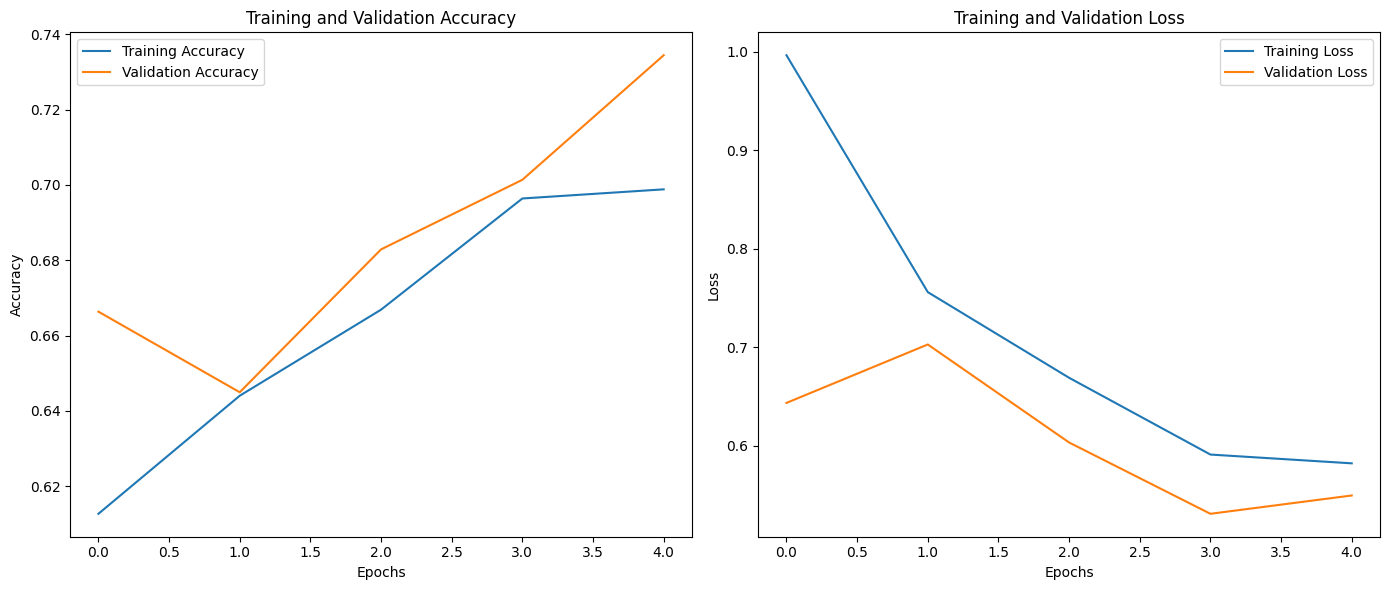

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.tight_layout()
    plt.show()

plot_history(history)


In [8]:
for epoch in range(len(history.history['accuracy'])):
    print(f"Epoch {epoch+1}:")
    print(f"  Training Accuracy:  {history.history['accuracy'][epoch]:.4f}")
    print(f"  Validation Accuracy:{history.history['val_accuracy'][epoch]:.4f}")
    print(f"  Training Loss:      {history.history['loss'][epoch]:.4f}")
    print(f"  Validation Loss:    {history.history['val_loss'][epoch]:.4f}")


Epoch 1:
  Training Accuracy:  0.6127
  Validation Accuracy:0.6663
  Training Loss:      0.9963
  Validation Loss:    0.6433
Epoch 2:
  Training Accuracy:  0.6440
  Validation Accuracy:0.6449
  Training Loss:      0.7558
  Validation Loss:    0.7026
Epoch 3:
  Training Accuracy:  0.6669
  Validation Accuracy:0.6829
  Training Loss:      0.6688
  Validation Loss:    0.6031
Epoch 4:
  Training Accuracy:  0.6964
  Validation Accuracy:0.7014
  Training Loss:      0.5909
  Validation Loss:    0.5307
Epoch 5:
  Training Accuracy:  0.6988
  Validation Accuracy:0.7344
  Training Loss:      0.5820
  Validation Loss:    0.5493


Generating predictions on validation set...
129/129 [==============================] - 6s 43ms/step

--- Classification Report ---
              precision    recall  f1-score   support

    diseased       0.53      0.57      0.55       566
     healthy       0.42      0.39      0.40       462

    accuracy                           0.49      1028
   macro avg       0.48      0.48      0.48      1028
weighted avg       0.48      0.49      0.48      1028



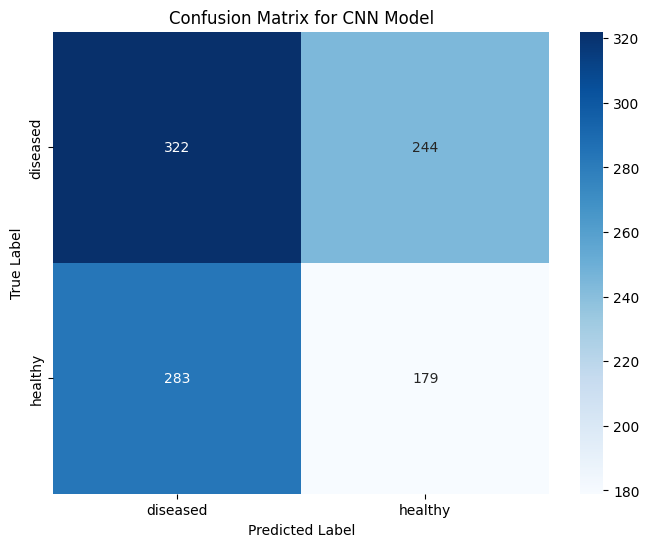

In [10]:
from sklearn.metrics import confusion_matrix, classification_report # type: ignore
import seaborn as sns # type: ignore

# 1. Get True Labels and Predictions from the Validation Set
print("Generating predictions on validation set...")

# Reset generator to ensure it starts from the beginning
val_gen.reset() 

# Predict the categories for all validation images
# steps = total number of validation samples / batch size
val_steps = val_gen.samples // val_gen.batch_size 
if val_gen.samples % val_gen.batch_size != 0:
    val_steps += 1
    
Y_pred = model.predict(val_gen, steps=val_steps)
y_pred_classes = np.argmax(Y_pred, axis=1) # Predicted classes (e.g., 0, 1)

# Get true classes (ensure generator is not shuffled)
y_true = val_gen.classes # True classes (e.g., 0, 1)

# Get class labels from the generator
class_names = list(train_gen.class_indices.keys())

# 2. Compute Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# 3. Print Classification Report (Precision, Recall, F1-score)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# 4. Plot Confusion Matrix (for report visualization)
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix for CNN Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [19]:
import numpy as np
import json
import tensorflow as tf
from PIL import Image
from tensorflow.keras.models import load_model  # type: ignore

# 1. LOAD ASSETS ONCE (Globally)
with tf.device('/CPU:0'):
    GLOBAL_MODEL = load_model(r'C:\NEWHELPTHEGREEN\plantvillage_tuned_model.h5')

with open('class_labels_combined.json', 'r') as f:
    labels = json.load(f)
    CLASS_LABELS = {int(k): v for k, v in labels.items()}

def load_preprocess_image(image_path, target_size=(128, 128)):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(target_size)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array.astype('float32') / 255

def predict_image(image_path):
    # 2. USE THE GLOBAL MODEL
    img_array = load_preprocess_image(image_path)
    
    # This call will no longer trigger retracing warnings
    with tf.device('/CPU:0'):
        prediction = GLOBAL_MODEL.predict(img_array, verbose=0) 
    
    top_3 = np.argsort(prediction[0])[-3:][::-1]
    print(f"\nResults for: {image_path}")
    for i in top_3:
        print(f"{CLASS_LABELS[i]}: {prediction[0][i]:.2%}")

# Now you can call this multiple times without warnings or lag
predict_image(r"C:\Users\majum\Downloads\download (1).jpeg")


Results for: C:\Users\majum\Downloads\download (1).jpeg
diseased: 72.97%
healthy: 27.03%
